In [2]:
!pip install transformers datasets huggingface_hub

In [1]:
# @title 1. 환경 설정 및 라이브러리 설치 (Cell 1)
"""
이 셀에서는 실습에 필요한 라이브러리들을 설치하고 임포트합니다.
- transformers: Hugging Face 모델 및 파이프라인 사용을 위한 라이브러리
- datasets: KLUE 데이터셋 등 Hugging Face Hub의 데이터셋 로드를 위한 라이브러리
- sentencepiece: KoBART 등 일부 모델에서 사용하는 토크나이저 라이브러리
- accelerate: 모델 로딩 및 분산 처리를 도와주는 라이브러리 (특히 NLLB 모델에 유용)
- torch: PyTorch 라이브러리 (기본 백엔드)
"""
# TODO: 필요한 라이브러리를 설치하는 명령어를 작성하세요. (transformers, datasets, sentencepiece, accelerate, torch)
# !pip install ...

import datasets
from datasets import load_dataset, DatasetDict
from transformers import pipeline
import torch
import pandas as pd # 데이터 확인용

# GPU 사용 가능 여부 확인 및 설정 (Colab에서는 보통 GPU 사용 가능)
device = 0 if torch.cuda.is_available() else -1
print(f"사용 가능한 디바이스: {'GPU' if device == 0 else 'CPU'}")

사용 가능한 디바이스: GPU


In [5]:
# @title 2. 데이터셋 로드 및 준비
from datasets import load_dataset

# NSMC 원본 TSV 파일을 직접 로드
data_files = {
    "train": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    "test": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"
}

full_dataset = load_dataset(
    "csv",
    data_files=data_files,
    delimiter="\t",
    split="train"
)

# 실습을 위해 데이터 일부만 선택
num_samples_to_use = 100
nsmc_subset = full_dataset.select(range(num_samples_to_use))

print("로드된 데이터셋 정보:")
print(nsmc_subset)

print("\n첫 번째 데이터 예시:")
print(nsmc_subset[0])

# Hugging Face Dataset → Pandas DataFrame 변환
df = pd.DataFrame(nsmc_subset)

print("\n데이터셋 일부 미리보기:")
display(df.head(10))

로드된 데이터셋 정보:
Dataset({
    features: ['id', 'document', 'label'],
    num_rows: 100
})

첫 번째 데이터 예시:
{'id': 9976970, 'document': '아 더빙.. 진짜 짜증나네요 목소리', 'label': 0}

데이터셋 일부 미리보기:


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1
5,5403919,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0
6,7797314,원작의 긴장감을 제대로 살려내지못했다.,0
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1
9,5912145,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1


In [6]:
# @title 3. Movie Review Analysis용 컬럼 구성 (Cell 3)

# document 컬럼명을 프로젝트 목적에 맞게 변경
df = df.rename(columns={
    "document": "original_review"
})

# 원래 NSMC label도 보기 쉽게 변환
df["sentiment"] = df["label"].map({
    0: "negative",
    1: "positive"
})

# Movie Review Analysis에서 사용할 결과 컬럼 추가
df["cleaned_review"] = ""
df["summary"] = ""
df["feedback_on_plot"] = ""
df["feedback_on_acting"] = ""
df["feedback_on_cinematography"] = ""
df["feedback_on_soundtrack"] = ""
df["useful_feedback"] = ""

# 컬럼 순서 정리
df = df[
    [
        "id",
        "original_review",
        "label",
        "sentiment",
        "cleaned_review",
        "summary",
        "feedback_on_plot",
        "feedback_on_acting",
        "feedback_on_cinematography",
        "feedback_on_soundtrack",
        "useful_feedback"
    ]
]

display(df.head(10))

,id,original_review,label,sentiment,cleaned_review,summary,feedback_on_plot,feedback_on_acting,feedback_on_cinematography,feedback_on_soundtrack,useful_feedback
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,negative,,,,,,,
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,positive,,,,,,,
2,10265843,너무재밓었다그래서보는것을추천한다,0,negative,,,,,,,
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,negative,,,,,,,
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,positive,,,,,,,
5,5403919,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0,negative,,,,,,,
6,7797314,원작의 긴장감을 제대로 살려내지못했다.,0,negative,,,,,,,
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0,negative,,,,,,,
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1,positive,,,,,,,
9,5912145,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1,positive,,,,,,,


In [7]:
# @title 4. 모델 파이프라인 로드 (Cell 4)
"""
이 셀에서는 영화 리뷰 분석을 위한 Hugging Face 파이프라인을 로드합니다.

사용 파이프라인:
1. sentiment_analyzer
   - 리뷰의 긍정/부정 감성을 분석합니다.
   - NSMC 영화 리뷰 데이터에 적합한 한국어 감성 분석 모델을 사용합니다.

2. aspect_classifier
   - 리뷰가 어떤 영화 요소에 대한 피드백인지 분류합니다.
   - 예: 줄거리, 연기, 촬영, 음악 등
"""

# 1. 한국어 영화 리뷰 감성 분석 파이프라인
sentiment_analyzer = pipeline(
    task="text-classification",
    model="daekeun-ml/koelectra-small-v3-nsmc",
    device=device
)

print("감성 분석 파이프라인 로드 완료.")


# 2. 리뷰 내용이 어떤 영화 요소에 관한 것인지 분류하는 파이프라인
aspect_classifier = pipeline(
    task="zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=device
)

print("영화 요소 분류 파이프라인 로드 완료.")

config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/56.5M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: daekeun-ml/koelectra-small-v3-nsmc
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

영화 요소 분류 파이프라인 로드 완료.


In [8]:
# @title 5. 영화 리뷰 분석 라벨 정의 (Cell 5)

aspect_labels = [
    "plot",
    "acting",
    "cinematography",
    "soundtrack"
]

print("분석할 영화 요소 라벨:")
print(aspect_labels)

분석할 영화 요소 라벨:
['plot', 'acting', 'cinematography', 'soundtrack']


In [9]:
# @title 6. 파이프라인 단일 리뷰 테스트 (Cell 6)

sample_review = df.loc[0, "original_review"]

print("원문 리뷰:")
print(sample_review)

print("\n감성 분석 결과:")
print(sentiment_analyzer(sample_review))

print("\n영화 요소 분류 결과:")
print(aspect_classifier(sample_review, aspect_labels))

원문 리뷰:
아 더빙.. 진짜 짜증나네요 목소리

감성 분석 결과:
[{'label': '0', 'score': 0.9992303848266602}]

영화 요소 분류 결과:
{'sequence': '아 더빙.. 진짜 짜증나네요 목소리', 'labels': ['acting', 'soundtrack', 'plot', 'cinematography'], 'scores': [0.7301149368286133, 0.1517011970281601, 0.05969782918691635, 0.05848602205514908]}


In [18]:
# @title 7. 리뷰 분석 함수 정의 - 문장 분리 + 다중 요소 분류 (Cell 7)

import re

def split_korean_sentences(text):
    """
    리뷰를 문장 또는 짧은 구간 단위로 나눕니다.
    긴 리뷰가 여러 영화 요소를 포함할 경우,
    각 부분을 따로 분류하기 위해 사용합니다.
    """
    if text is None:
        return []

    text = str(text).strip()

    # 마침표, 느낌표, 물음표, 줄바꿈 기준으로 1차 분리
    sentences = re.split(r"[.!?。！？\n]+", text)

    # 쉼표, '그리고', '하지만', '근데', '다만' 등도 일부 분리 기준으로 사용
    refined_parts = []

    for sentence in sentences:
        sentence = sentence.strip()
        if sentence == "":
            continue

        parts = re.split(r",|그리고|하지만|근데|다만|반면에|또한", sentence)
        parts = [p.strip() for p in parts if p.strip()]

        refined_parts.extend(parts)

    return refined_parts


def analyze_review(review):
    """
    하나의 영화 리뷰를 입력받아 다음을 수행합니다.

    1. 감성 분석
    2. 리뷰 정제
    3. 문장/구간 단위 분리
    4. 각 구간별 영화 요소 분류
    5. 여러 요소별 피드백 컬럼 생성
    6. 최종 구조화 피드백 생성
    """

    if review is None or str(review).strip() == "":
        return {
            "cleaned_review": "",
            "summary": "",
            "predicted_sentiment": "",
            "feedback_on_plot": "",
            "feedback_on_acting": "",
            "feedback_on_cinematography": "",
            "feedback_on_soundtrack": "",
            "useful_feedback": ""
        }

    review = str(review).strip()

    # 1. 감성 분석
    sentiment_result = sentiment_analyzer(review)[0]
    sentiment_label = sentiment_result["label"]
    sentiment_score = round(sentiment_result["score"], 3)

    # 2. 간단한 리뷰 정제
    cleaned_review = (
        review
        .replace("ㅋㅋ", "")
        .replace("ㅎㅎ", "")
        .replace("ㅋ", "")
        .replace("ㅎ", "")
        .strip()
    )

    # 3. NSMC 리뷰는 짧으므로 summary는 정제된 리뷰와 동일하게 설정
    summary = cleaned_review

    # 4. 리뷰를 여러 구간으로 분리
    review_parts = split_korean_sentences(cleaned_review)

    # 분리가 되지 않으면 전체 리뷰를 하나의 구간으로 사용
    if len(review_parts) == 0:
        review_parts = [cleaned_review]

    # 5. 요소별 피드백 저장 공간
    aspect_feedbacks = {
        "plot": [],
        "acting": [],
        "cinematography": [],
        "soundtrack": []
    }

    # 관련도 기준값
    # 너무 많이 잡히면 0.45~0.5로 올리고,
    # 너무 적게 잡히면 0.25~0.3으로 낮추면 됩니다.
    aspect_threshold = 0.35

    # 6. 각 구간별로 영화 요소 분류
    for part in review_parts:
        aspect_result = aspect_classifier(
            part,
            aspect_labels,
            multi_label=True
        )

        aspect_scores = dict(zip(
            aspect_result["labels"],
            aspect_result["scores"]
        ))

        for aspect in aspect_labels:
            score = aspect_scores.get(aspect, 0)

            if score >= aspect_threshold:
                aspect_feedbacks[aspect].append(
                    f"{part} / 관련도 점수: {round(score, 3)}"
                )

    # 7. 각 요소별 피드백 컬럼 내용 만들기
    feedback_on_plot = " | ".join(aspect_feedbacks["plot"])
    feedback_on_acting = " | ".join(aspect_feedbacks["acting"])
    feedback_on_cinematography = " | ".join(aspect_feedbacks["cinematography"])
    feedback_on_soundtrack = " | ".join(aspect_feedbacks["soundtrack"])

    # 8. 감지된 요소 목록 만들기
    detected_aspects = [
        aspect for aspect, feedbacks in aspect_feedbacks.items()
        if len(feedbacks) > 0
    ]

    if len(detected_aspects) == 0:
        detected_aspects_text = "특정 영화 요소가 뚜렷하게 감지되지 않음"
    else:
        detected_aspects_text = ", ".join(detected_aspects)

    # 9. 최종 구조화 피드백 생성
    useful_feedback = (
        f"이 리뷰는 {detected_aspects_text}에 대한 의견을 포함하며, "
        f"전체 감성은 {sentiment_label}로 분석되었습니다. "
        f"핵심 의견: {summary}"
    )

    return {
        "cleaned_review": cleaned_review,
        "summary": summary,
        "predicted_sentiment": f"{sentiment_label} ({sentiment_score})",
        "feedback_on_plot": feedback_on_plot,
        "feedback_on_acting": feedback_on_acting,
        "feedback_on_cinematography": feedback_on_cinematography,
        "feedback_on_soundtrack": feedback_on_soundtrack,
        "useful_feedback": useful_feedback
    }

In [19]:
# @title 8. DataFrame에 모델 적용하기 (Cell 8)

# 처음에는 10개만 테스트
test_df = df.head(10).copy()

results = test_df["original_review"].apply(analyze_review)

# dict 결과를 DataFrame으로 변환
results_df = pd.DataFrame(list(results))

# 기존 데이터와 분석 결과 합치기
final_df = pd.concat(
    [
        test_df.drop(
            columns=[
                "cleaned_review",
                "summary",
                "feedback_on_plot",
                "feedback_on_acting",
                "feedback_on_cinematography",
                "feedback_on_soundtrack",
                "useful_feedback"
            ],
            errors="ignore"
        ),
        results_df
    ],
    axis=1
)

display(final_df)

,id,original_review,label,sentiment,cleaned_review,summary,predicted_sentiment,feedback_on_plot,feedback_on_acting,feedback_on_cinematography,feedback_on_soundtrack,useful_feedback
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,negative,아 더빙.. 진짜 짜증나네요 목소리,아 더빙.. 진짜 짜증나네요 목소리,0 (0.999),진짜 짜증나네요 목소리 / 관련도 점수: 0.505,,,진짜 짜증나네요 목소리 / 관련도 점수: 0.362,"이 리뷰는 plot, soundtrack에 대한 의견을 포함하며, 전체 감성은 0로..."
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,positive,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1 (0.993),흠 / 관련도 점수: 0.368 | 포스터보고 초딩영화줄 / 관련도 점수: 0.81...,오버연기조차 가볍지 않구나 / 관련도 점수: 0.969,포스터보고 초딩영화줄 / 관련도 점수: 0.987 | 오버연기조차 가볍지 않구나 /...,오버연기조차 가볍지 않구나 / 관련도 점수: 0.527,"이 리뷰는 plot, acting, cinematography, soundtrack..."
2,10265843,너무재밓었다그래서보는것을추천한다,0,negative,너무재밓었다그래서보는것을추천한다,너무재밓었다그래서보는것을추천한다,1 (0.586),,너무재밓었다그래서보는것을추천한다 / 관련도 점수: 0.552,너무재밓었다그래서보는것을추천한다 / 관련도 점수: 0.494,,"이 리뷰는 acting, cinematography에 대한 의견을 포함하며, 전체 ..."
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,negative,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0 (0.999),교도소 이야기구먼 / 관련도 점수: 0.981 | 솔직히 재미는 없다 / 관련도 점...,,,,"이 리뷰는 plot에 대한 의견을 포함하며, 전체 감성은 0로 분석되었습니다. 핵심..."
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,positive,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1 (0.999),사이몬페그의 익살스런 연기가 돋보였던 영화 / 관련도 점수: 0.867 | 스파이더...,사이몬페그의 익살스런 연기가 돋보였던 영화 / 관련도 점수: 0.999 | 스파이더...,사이몬페그의 익살스런 연기가 돋보였던 영화 / 관련도 점수: 0.988 | 스파이더...,스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다 / 관련도 점수...,"이 리뷰는 plot, acting, cinematography, soundtrack..."
5,5403919,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0,negative,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화....별반개도 아까움.,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화....별반개도 아까움.,0 (1.0),막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화 / 관련도 점수: 0.501,,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화 / 관련도 점수: 0.922,,"이 리뷰는 plot, cinematography에 대한 의견을 포함하며, 전체 감성..."
6,7797314,원작의 긴장감을 제대로 살려내지못했다.,0,negative,원작의 긴장감을 제대로 살려내지못했다.,원작의 긴장감을 제대로 살려내지못했다.,0 (0.999),원작의 긴장감을 제대로 살려내지못했다 / 관련도 점수: 0.979,원작의 긴장감을 제대로 살려내지못했다 / 관련도 점수: 0.65,원작의 긴장감을 제대로 살려내지못했다 / 관련도 점수: 0.753,,"이 리뷰는 plot, acting, cinematography에 대한 의견을 포함하..."
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0,negative,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0 (1.0),정말 발로해도 그것보단 낫겟다 납치 / 관련도 점수: 0.904 | 감금만반복반복 ...,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지 / 관련도 점수: 0.9...,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지 / 관련도 점수: 0.9...,감금만반복반복 / 관련도 점수: 0.672,"이 리뷰는 plot, acting, cinematography, soundtrack..."
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1,positive,액션이 없는데도 재미 있는 몇안되는 영화,액션이 없는데도 재미 있는 몇안되는 영화,1 (0.999),액션이 없는데도 재미 있는 몇안되는 영화 / 관련도 점수: 0.496,,액션이 없는데도 재미 있는 몇안되는 영화 / 관련도 점수: 0.772,,"이 리뷰는 plot, cinematography에 대한 의견을 포함하며, 전체 감성..."
9,5912145,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1,positive,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1 (0.999),꽤 볼만한데 / 관련도 점수: 0.37,꽤 볼만한데 / 관련도 점수: 0.63,꽤 볼만한데 / 관련도 점수: 0.695 | 헐리우드식 화려함에만 너무 길들여져 있...,,"이 리뷰는 plot, acting, cinematography에 대한 의견을 포함하..."


In [21]:
# @title 9. 전체 샘플에 적용하기 (Cell 9)

working_df = df.head(100).copy()

results = working_df["original_review"].apply(analyze_review)
results_df = pd.DataFrame(list(results))

final_df = pd.concat(
    [
        working_df.drop(
            columns=[
                "cleaned_review",
                "summary",
                "feedback_on_plot",
                "feedback_on_acting",
                "feedback_on_cinematography",
                "feedback_on_soundtrack",
                "useful_feedback"
            ],
            errors="ignore"
        ),
        results_df
    ],
    axis=1
)

display(final_df.head(20))

,id,original_review,label,sentiment,cleaned_review,summary,predicted_sentiment,feedback_on_plot,feedback_on_acting,feedback_on_cinematography,feedback_on_soundtrack,useful_feedback
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,negative,아 더빙.. 진짜 짜증나네요 목소리,아 더빙.. 진짜 짜증나네요 목소리,0 (0.999),진짜 짜증나네요 목소리 / 관련도 점수: 0.505,,,진짜 짜증나네요 목소리 / 관련도 점수: 0.362,"이 리뷰는 plot, soundtrack에 대한 의견을 포함하며, 전체 감성은 0로..."
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,positive,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1 (0.993),흠 / 관련도 점수: 0.368 | 포스터보고 초딩영화줄 / 관련도 점수: 0.81...,오버연기조차 가볍지 않구나 / 관련도 점수: 0.969,포스터보고 초딩영화줄 / 관련도 점수: 0.987 | 오버연기조차 가볍지 않구나 /...,오버연기조차 가볍지 않구나 / 관련도 점수: 0.527,"이 리뷰는 plot, acting, cinematography, soundtrack..."
2,10265843,너무재밓었다그래서보는것을추천한다,0,negative,너무재밓었다그래서보는것을추천한다,너무재밓었다그래서보는것을추천한다,1 (0.586),,너무재밓었다그래서보는것을추천한다 / 관련도 점수: 0.552,너무재밓었다그래서보는것을추천한다 / 관련도 점수: 0.494,,"이 리뷰는 acting, cinematography에 대한 의견을 포함하며, 전체 ..."
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,negative,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0 (0.999),교도소 이야기구먼 / 관련도 점수: 0.981 | 솔직히 재미는 없다 / 관련도 점...,,,,"이 리뷰는 plot에 대한 의견을 포함하며, 전체 감성은 0로 분석되었습니다. 핵심..."
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,positive,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1 (0.999),사이몬페그의 익살스런 연기가 돋보였던 영화 / 관련도 점수: 0.867 | 스파이더...,사이몬페그의 익살스런 연기가 돋보였던 영화 / 관련도 점수: 0.999 | 스파이더...,사이몬페그의 익살스런 연기가 돋보였던 영화 / 관련도 점수: 0.988 | 스파이더...,스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다 / 관련도 점수...,"이 리뷰는 plot, acting, cinematography, soundtrack..."
5,5403919,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0,negative,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화....별반개도 아까움.,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화....별반개도 아까움.,0 (1.0),막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화 / 관련도 점수: 0.501,,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화 / 관련도 점수: 0.922,,"이 리뷰는 plot, cinematography에 대한 의견을 포함하며, 전체 감성..."
6,7797314,원작의 긴장감을 제대로 살려내지못했다.,0,negative,원작의 긴장감을 제대로 살려내지못했다.,원작의 긴장감을 제대로 살려내지못했다.,0 (0.999),원작의 긴장감을 제대로 살려내지못했다 / 관련도 점수: 0.979,원작의 긴장감을 제대로 살려내지못했다 / 관련도 점수: 0.65,원작의 긴장감을 제대로 살려내지못했다 / 관련도 점수: 0.753,,"이 리뷰는 plot, acting, cinematography에 대한 의견을 포함하..."
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0,negative,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0 (1.0),정말 발로해도 그것보단 낫겟다 납치 / 관련도 점수: 0.904 | 감금만반복반복 ...,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지 / 관련도 점수: 0.9...,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지 / 관련도 점수: 0.9...,감금만반복반복 / 관련도 점수: 0.672,"이 리뷰는 plot, acting, cinematography, soundtrack..."
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1,positive,액션이 없는데도 재미 있는 몇안되는 영화,액션이 없는데도 재미 있는 몇안되는 영화,1 (0.999),액션이 없는데도 재미 있는 몇안되는 영화 / 관련도 점수: 0.496,,액션이 없는데도 재미 있는 몇안되는 영화 / 관련도 점수: 0.772,,"이 리뷰는 plot, cinematography에 대한 의견을 포함하며, 전체 감성..."
9,5912145,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1,positive,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1 (0.999),꽤 볼만한데 / 관련도 점수: 0.37,꽤 볼만한데 / 관련도 점수: 0.63,꽤 볼만한데 / 관련도 점수: 0.695 | 헐리우드식 화려함에만 너무 길들여져 있...,,"이 리뷰는 plot, acting, cinematography에 대한 의견을 포함하..."


In [22]:
# @title 10. 결과 분석 및 확인 (Cell 10)

print("감성 분석 결과 분포:")
display(final_df["predicted_sentiment"].value_counts())

print("\n영화 요소별 피드백 개수:")
aspect_counts = {
    "plot": final_df["feedback_on_plot"].astype(bool).sum(),
    "acting": final_df["feedback_on_acting"].astype(bool).sum(),
    "cinematography": final_df["feedback_on_cinematography"].astype(bool).sum(),
    "soundtrack": final_df["feedback_on_soundtrack"].astype(bool).sum()
}

display(pd.DataFrame(aspect_counts.items(), columns=["aspect", "count"]))

감성 분석 결과 분포:


,count
predicted_sentiment,
0 (0.999),22
1 (0.999),21
0 (1.0),13
1 (1.0),4
1 (0.998),4
1 (0.993),3
1 (0.996),2
1 (0.997),2
0 (0.995),2



영화 요소별 피드백 개수:


,aspect,count
0,plot,84
1,acting,66
2,cinematography,68
3,soundtrack,26


In [23]:
# @title 11. Hugging Face Dataset map 함수 (Cell 11)

def add_basic_columns(example):
    review = str(example["original_review"]).strip()

    example["cleaned_review"] = review.replace("ㅋ", "").replace("ㅎ", "").strip()
    example["summary"] = example["cleaned_review"]

    return example

mapped_dataset = train_data.map(add_basic_columns)

print(mapped_dataset)
print(mapped_dataset[0])

Dataset({
    features: ['id', 'original_review', 'label', 'cleaned_review', 'summary'],
    num_rows: 100
})
{'id': 9976970, 'original_review': '아 더빙.. 진짜 짜증나네요 목소리', 'label': 0, 'cleaned_review': '아 더빙.. 진짜 짜증나네요 목소리', 'summary': '아 더빙.. 진짜 짜증나네요 목소리'}


In [24]:
# @title 12. 최종 결과 확인 (Cell 12)

print("최종 데이터프레임 크기:")
print(final_df.shape)

print("\n최종 컬럼 목록:")
print(final_df.columns.tolist())

print("\n분석 결과 일부 확인:")
display(final_df[
    [
        "original_review",
        "predicted_sentiment",
        "feedback_on_plot",
        "feedback_on_acting",
        "feedback_on_cinematography",
        "feedback_on_soundtrack",
        "useful_feedback"
    ]
].head(10))

최종 데이터프레임 크기:
(100, 12)

최종 컬럼 목록:
['id', 'original_review', 'label', 'sentiment', 'cleaned_review', 'summary', 'predicted_sentiment', 'feedback_on_plot', 'feedback_on_acting', 'feedback_on_cinematography', 'feedback_on_soundtrack', 'useful_feedback']

분석 결과 일부 확인:


,original_review,predicted_sentiment,feedback_on_plot,feedback_on_acting,feedback_on_cinematography,feedback_on_soundtrack,useful_feedback
0,아 더빙.. 진짜 짜증나네요 목소리,0 (0.999),진짜 짜증나네요 목소리 / 관련도 점수: 0.505,,,진짜 짜증나네요 목소리 / 관련도 점수: 0.362,"이 리뷰는 plot, soundtrack에 대한 의견을 포함하며, 전체 감성은 0로..."
1,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1 (0.993),흠 / 관련도 점수: 0.368 | 포스터보고 초딩영화줄 / 관련도 점수: 0.81...,오버연기조차 가볍지 않구나 / 관련도 점수: 0.969,포스터보고 초딩영화줄 / 관련도 점수: 0.987 | 오버연기조차 가볍지 않구나 /...,오버연기조차 가볍지 않구나 / 관련도 점수: 0.527,"이 리뷰는 plot, acting, cinematography, soundtrack..."
2,너무재밓었다그래서보는것을추천한다,1 (0.586),,너무재밓었다그래서보는것을추천한다 / 관련도 점수: 0.552,너무재밓었다그래서보는것을추천한다 / 관련도 점수: 0.494,,"이 리뷰는 acting, cinematography에 대한 의견을 포함하며, 전체 ..."
3,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0 (0.999),교도소 이야기구먼 / 관련도 점수: 0.981 | 솔직히 재미는 없다 / 관련도 점...,,,,"이 리뷰는 plot에 대한 의견을 포함하며, 전체 감성은 0로 분석되었습니다. 핵심..."
4,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1 (0.999),사이몬페그의 익살스런 연기가 돋보였던 영화 / 관련도 점수: 0.867 | 스파이더...,사이몬페그의 익살스런 연기가 돋보였던 영화 / 관련도 점수: 0.999 | 스파이더...,사이몬페그의 익살스런 연기가 돋보였던 영화 / 관련도 점수: 0.988 | 스파이더...,스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다 / 관련도 점수...,"이 리뷰는 plot, acting, cinematography, soundtrack..."
5,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0 (1.0),막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화 / 관련도 점수: 0.501,,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화 / 관련도 점수: 0.922,,"이 리뷰는 plot, cinematography에 대한 의견을 포함하며, 전체 감성..."
6,원작의 긴장감을 제대로 살려내지못했다.,0 (0.999),원작의 긴장감을 제대로 살려내지못했다 / 관련도 점수: 0.979,원작의 긴장감을 제대로 살려내지못했다 / 관련도 점수: 0.65,원작의 긴장감을 제대로 살려내지못했다 / 관련도 점수: 0.753,,"이 리뷰는 plot, acting, cinematography에 대한 의견을 포함하..."
7,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0 (1.0),정말 발로해도 그것보단 낫겟다 납치 / 관련도 점수: 0.904 | 감금만반복반복 ...,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지 / 관련도 점수: 0.9...,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지 / 관련도 점수: 0.9...,감금만반복반복 / 관련도 점수: 0.672,"이 리뷰는 plot, acting, cinematography, soundtrack..."
8,액션이 없는데도 재미 있는 몇안되는 영화,1 (0.999),액션이 없는데도 재미 있는 몇안되는 영화 / 관련도 점수: 0.496,,액션이 없는데도 재미 있는 몇안되는 영화 / 관련도 점수: 0.772,,"이 리뷰는 plot, cinematography에 대한 의견을 포함하며, 전체 감성..."
9,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1 (0.999),꽤 볼만한데 / 관련도 점수: 0.37,꽤 볼만한데 / 관련도 점수: 0.63,꽤 볼만한데 / 관련도 점수: 0.695 | 헐리우드식 화려함에만 너무 길들여져 있...,,"이 리뷰는 plot, acting, cinematography에 대한 의견을 포함하..."


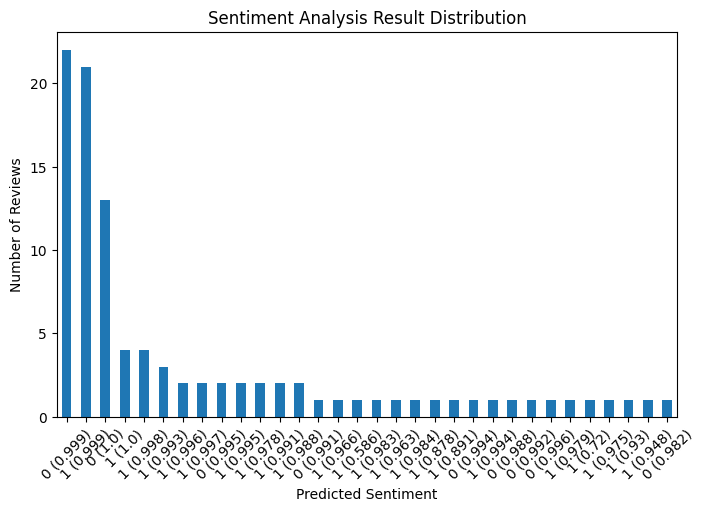

In [30]:
# @title 13. 감성 분석 결과 시각화 (Cell 13)

import matplotlib.pyplot as plt1

sentiment_counts = final_df["predicted_sentiment"].value_counts()

plt1.figure(figsize=(8, 5))
sentiment_counts.plot(kind="bar")
plt1.title("Sentiment Analysis Result Distribution")
plt1.xlabel("Predicted Sentiment")
plt1.ylabel("Number of Reviews")
plt1.xticks(rotation=45)
plt1.show()




,aspect,count
0,plot,84
1,acting,66
2,cinematography,68
3,soundtrack,26


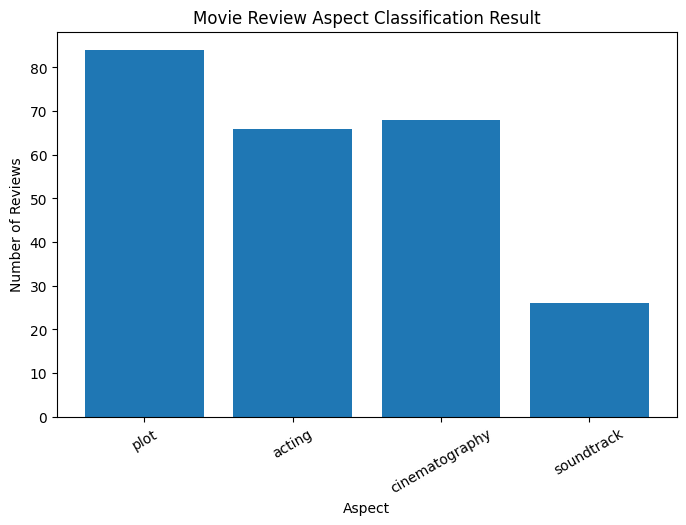

In [31]:
# @title 14. 영화 요소별 피드백 개수 시각화 (Cell 14)
import matplotlib.pyplot as plt2

aspect_counts = {
    "plot": final_df["feedback_on_plot"].astype(bool).sum(),
    "acting": final_df["feedback_on_acting"].astype(bool).sum(),
    "cinematography": final_df["feedback_on_cinematography"].astype(bool).sum(),
    "soundtrack": final_df["feedback_on_soundtrack"].astype(bool).sum()
}

aspect_df = pd.DataFrame(
    list(aspect_counts.items()),
    columns=["aspect", "count"]
)

display(aspect_df)

plt2.figure(figsize=(8, 5))
plt2.bar(aspect_df["aspect"], aspect_df["count"])
plt2.title("Movie Review Aspect Classification Result")
plt2.xlabel("Aspect")
plt2.ylabel("Number of Reviews")
plt2.xticks(rotation=30)
plt2.show()

In [28]:
# @title 15. 최종 결과 Google Drive에 저장

from google.colab import drive
drive.mount('/content/drive')

output_path = "/content/drive/MyDrive/git/4-huggingface/ASSIGNMENT/lecture_magnifier_nsmc_results.csv"

final_df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Google Drive에 저장 완료: {output_path}")

Mounted at /content/drive
Google Drive에 저장 완료: /content/drive/MyDrive/git/4-huggingface/ASSIGNMENT/lecture_magnifier_nsmc_results.csv


In [32]:
plt1.tight_layout()

sentiment_graph_path = "/content/drive/MyDrive/git/4-huggingface/ASSIGNMENT/sentiment_distribution.png"
plt1.savefig(sentiment_graph_path, dpi=300, bbox_inches="tight")

print(f"감성 분석 그래프 저장 완료: {sentiment_graph_path}")

plt2.tight_layout()

aspect_graph_path = "/content/drive/MyDrive/git/4-huggingface/ASSIGNMENT/aspect_classification_result.png"
plt2.savefig(aspect_graph_path, dpi=300, bbox_inches="tight")

print(f"영화 요소 분류 그래프 저장 완료: {aspect_graph_path}")

감성 분석 그래프 저장 완료: /content/drive/MyDrive/git/4-huggingface/ASSIGNMENT/sentiment_distribution.png
영화 요소 분류 그래프 저장 완료: /content/drive/MyDrive/git/4-huggingface/ASSIGNMENT/aspect_classification_result.png


<Figure size 640x480 with 0 Axes>